In [1]:
import os

import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.spatial import cKDTree
from matplotlib import pyplot as plt

In [2]:
if os.getcwd().endswith("notebooks"):
    os.chdir("../")
print(f"Cwd: {os.getcwd()}")

Cwd: /Volumes/X31/01.Projects/atem


In [3]:
path:str = "data/Depth_to_Watertable/depth-to-water.csv"

In [4]:
df = pd.read_csv(path)

In [5]:
df.head(10)

,GicWellId,WellId,Longitude,Latitude,WellReportId,TotalDepthDrilled,DrillingMethod,DrillingEndDate,ArtesianFlowFlag,PumpTestId,TestDate,StaticWaterLevel,IntervalFrom,IntervalTo
0,40023,40023,-112.362166,52.393997,40023,45.7200,Rotary,2001-10-18,0,10307075,2001-10-16,11.27760,15.8496,45.7200
1,40028,40028,-113.758582,52.365395,40028,55.1688,Cable Tool,2001-10-11,0,10307080,2001-10-11,45.26280,42.6720,54.5592
2,40059,40059,-112.910941,52.446859,40059,6.0960,Auger,1981-05-20,0,10307111,1981-08-29,5.39496,3.0480,6.0960
3,40060,40060,-113.024520,52.450421,40060,22.8600,Auger,1981-05-20,0,10307112,1981-08-22,8.22960,5.4864,13.1064
4,40061,40061,-113.000581,52.483085,40061,12.1920,Auger,1981-05-07,0,10307113,1981-08-28,11.88720,11.5824,12.1920
5,40062,40062,-112.952614,52.490308,40062,6.0960,Auger,1981-05-06,0,10307114,1981-08-27,5.79120,1.5240,6.0960
6,40067,40067,-113.150686,52.454001,40067,5.7912,Auger,1981-05-05,0,10307119,1981-08-26,2.28600,1.2192,5.7912
7,40069,40069,-113.048552,52.475831,40069,6.0960,Auger,1981-05-06,0,10307121,1981-08-27,2.74320,1.5240,6.0960
8,40071,40071,-113.180595,52.406825,40071,24.3840,Auger,1981-05-20,0,10307123,1981-08-28,3.56616,4.3840,24.3840
9,40081,40081,-112.784755,52.526818,40081,7.3152,Auger,1981-05-21,0,10307133,1981-08-25,3.35280,1.5240,7.3152


In [5]:
df[df["WellId"] == 153840.]

,GicWellId,WellId,Longitude,Latitude,WellReportId,TotalDepthDrilled,DrillingMethod,DrillingEndDate,ArtesianFlowFlag,PumpTestId,TestDate,StaticWaterLevel,IntervalFrom,IntervalTo
17371,153840,153840,-113.696547,50.178973,153840,64.6176,Rotary,1988-10-15,0,10201302,1988-10-14,48.768,44.6176,64.6176


In [6]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
    )
gdf = gdf.to_crs("EPSG:26912")

In [7]:
gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

In [8]:
gdf[gdf["WellId"] == 153840.]

,GicWellId,WellId,Longitude,Latitude,WellReportId,TotalDepthDrilled,DrillingMethod,DrillingEndDate,ArtesianFlowFlag,PumpTestId,TestDate,StaticWaterLevel,IntervalFrom,IntervalTo,geometry,x,y
17371,153840,153840,-113.696547,50.178973,153840,64.6176,Rotary,1988-10-15,0,10201302,1988-10-14,48.768,44.6176,64.6176,POINT (307477.454 5562010.793),307477.453838,5.562011e+06


In [10]:
atem_data:str = "outputs/merged_inversion_results/merged_iteration_14_resistivity_wide-1.csv"
atem_df = pd.read_csv(atem_data)
tx, ty = atem_df["x_wgs84"].to_numpy(dtype=float), atem_df["y_wgs84"].to_numpy(dtype=float)

In [11]:
model_tree = cKDTree(gdf[["x", "y"]])
distance, valid_index = model_tree.query([307477, 5.562011e6], k=10)

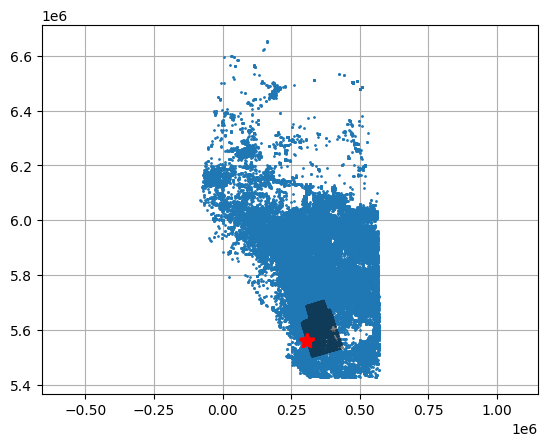

In [ ]:
plt.plot(gdf["x"], gdf["y"], "o", markersize=1)
plt.plot(tx, ty, c="black", label="ATEM Tx", alpha=0.5)
plt.plot(gdf.iloc[valid_index]["x"], gdf.iloc[valid_index]["y"], "*", color="red", ms=10)
plt.axis("equal")
plt.xlim()
plt.grid()

In [18]:
print(gdf.loc[valid_index, "x"])

17371    307477.453838
15149    307775.332192
15164    307000.230184
15130    308568.452708
15163    306207.452199
15162    306415.885597
15131    309401.443073
15150    305315.374290
15151    305315.374290
15165    306237.682717
Name: x, dtype: float64
